# Capítulos 6 y 7: Sistemas conservativos, funciones de Lyapunov y dinámica global

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/04-lyapunov-global.ipynb)

Notebook que acompaña a los Capítulos 6 y 7 de *Introducción al Modelado Continuo*. Reproduce las figuras de los dos capítulos (energía y potencial del péndulo, van der Pol, el atractor de Lorenz, el ejemplo de ciclo límite y las nulclinas del modelo de competencia) y verifica numéricamente lo que el texto afirma: que la energía se conserva, que una función de Lyapunov decrece a lo largo de las soluciones, la amplitud y el período del ciclo de van der Pol y la estabilidad de los equilibrios de competencia.

Las herramientas son las de estos capítulos: cantidades conservadas y funciones de Lyapunov (con el principio de LaSalle), el Teorema de Poincaré–Bendixson y el estudio gráfico con nulclinas. Para clasificar los equilibrios usamos la linealización del Capítulo 5 (`fases.jacobiano`, `fases.clasificar`). Cada figura de las notas sale de una celda marcada con su nombre de archivo.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from imc import estilo, fases
from imc.estilo import COLORES, CICLO

estilo.activar()
plt.close(plt.figure())   # inicializa el backend inline fuera de los rc_context de abajo (si no, las figuras no se muestran)
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/
# Legibilidad: cada celda de figura fija la fuente con `with fuente(F):` según el ancho con que
# el texto la incluye (0.6\textwidth para un panel, 0.9\textwidth para varios), para que impresa quede >= 8 pt.


def fuente(F):
    '''Contexto con fuente F en ejes, ticks y leyenda (los mismos tamaños que estilo.activar(fuente=F)), sin tocar los rcParams globales.'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 1})


def simular(F, X0, T, args=(), n=2000):
    '''Integra X' = F(t, X) en [0, T] con tolerancias finas y devuelve (t, X) en n instantes.'''
    sol = solve_ivp(F, (0, T), X0, args=args, rtol=1e-10, atol=1e-12, dense_output=True, max_step=T / n)
    t = np.linspace(0, T, n)
    return t, sol.sol(t)


def flechas_en_niveles(ax, cs, F, args=(), color=None, posiciones=(0.25, 0.75)):
    '''Dibuja una flecha con el sentido del campo F sobre cada curva de nivel de `cs`
    (un ContourSet), en las fracciones `posiciones` de cada tramo.'''
    color = color or COLORES["traj"]
    for path in cs.get_paths():
        v, c = path.vertices, path.codes
        cortes = np.where(c == 1)[0] if c is not None else np.array([0])
        for a, b in zip(cortes, list(cortes[1:]) + [len(v)]):
            tramo = v[a:b]
            if len(tramo) < 8:
                continue
            for f in posiciones:
                p = tramo[int(f * (len(tramo) - 1))]
                d = np.asarray(F(0.0, p, *args), dtype=float); d /= np.hypot(*d)
                ax.annotate("", xy=p + 1e-3 * d, xytext=p, arrowprops=dict(arrowstyle="-|>", color=color, mutation_scale=13))

## 6.1 Sistemas conservativos: el péndulo

Para $\dot x = y,\ \dot y = -U'(x)$ la energía $E(x,y) = \tfrac12 y^2 + U(x)$ es constante sobre las trayectorias, de modo que cada trayectoria está contenida en una curva de nivel de $E$; en $\{y>0\}$ se recorre de izquierda a derecha y en $\{y<0\}$ de derecha a izquierda. Los equilibrios son $(x^*, 0)$ con $U'(x^*)=0$.

Péndulo simple: $x = \theta$, $y = \dot\theta$, $U(x) = \omega^2(1-\cos x)$, con $\omega^2 = g/\ell$.

**Figura `energia_pendulo`**: curvas de nivel de $E$. Los mínimos de $U$ ($x = 2k\pi$) son centros; los máximos ($x = (2k+1)\pi$) son sillas, unidos por la curva de nivel $E = 2\omega^2$ (la separatriz entre oscilaciones y rotaciones).

X0 = [2.5, 0.0]: E(0) = 1.8011,  max|E(t) - E(0)| = 4.0e-11


X0 = [0.0, 2.5]: E(0) = 3.1250,  max|E(t) - E(0)| = 6.4e-11


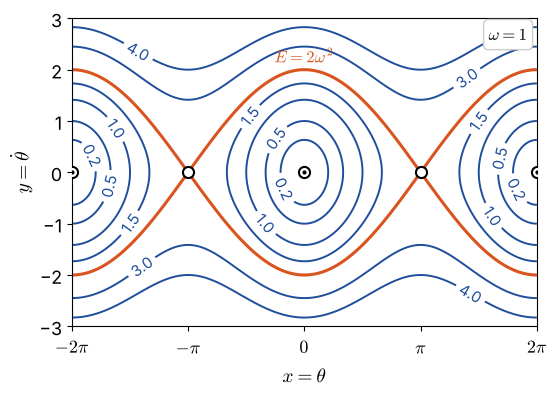

In [2]:
w = 1.0   # omega

def pendulo(t, X, w):
    x, y = X
    return [y, -w**2 * np.sin(x)]

U_pend = lambda x: w**2 * (1 - np.cos(x))
E_pend = lambda x, y: 0.5 * y**2 + U_pend(x)

# Verificación: E se conserva a lo largo de una oscilación y de una rotación
for X0 in ([2.5, 0.0], [0.0, 2.5]):
    t, (x, y) = simular(pendulo, X0, 40, args=(w,))
    print(f"X0 = {X0}: E(0) = {E_pend(*X0):.4f},  max|E(t) - E(0)| = {np.abs(E_pend(x, y) - E_pend(*X0)).max():.1e}")

L = 2 * np.pi
xx = np.linspace(-L, L, 400); yy = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(xx, yy)
with fuente(14):
    fig, ax = plt.subplots(figsize=(6, 4))
    cs = ax.contour(X, Y, E_pend(X, Y), levels=[0.2, 0.5, 1.0, 1.5, 3.0, 4.0], colors=[COLORES["traj"]], linewidths=1.4)
    ax.clabel(cs, fmt="%.1f", fontsize=11, inline=True)
    ax.contour(X, Y, E_pend(X, Y), levels=[2 * w**2], colors=[COLORES["nul_h"]], linewidths=2.2)
    ax.text(0.0, 2.06, r"$E = 2\omega^2$", color=COLORES["nul_h"], fontsize=12, ha="center", va="bottom")
    fases.marcar_equilibrios(ax, [(0, 0, "centro"), (L, 0, "centro"), (-L, 0, "centro"), (np.pi, 0, "silla"), (-np.pi, 0, "silla")])
    ax.set_xlim(-L, L); ax.set_ylim(-3, 3)
    ax.set_xticks([-L, -np.pi, 0, np.pi, L]); ax.set_xticklabels([r"$-2\pi$", r"$-\pi$", "$0$", r"$\pi$", r"$2\pi$"])
    ax.set_xlabel(r"$x = \theta$"); ax.set_ylabel(r"$y = \dot\theta$")
    estilo.parametros(ax, rf"$\omega = {w:g}$", loc="upper right", fontsize=12)
    if GUARDAR: estilo.guardar(fig, "energia_pendulo")

### Potencial y diagrama de fases, alineados

**Figuras `pendulo_potencial` y `potencial`**: arriba $U(x)$, abajo las curvas de nivel de $E$ con el sentido del campo, con el mismo eje $x$. Una trayectoria que pasa por $(\bar x, 0)$ tiene energía $U(\bar x)$ y no escapa del pozo de potencial $\{U(x)\le U(\bar x)\}$: las líneas punteadas horizontales de arriba marcan los niveles de energía de las curvas de abajo, y cada curva se mueve exactamente en el intervalo de $x$ donde $U$ queda por debajo de su línea.

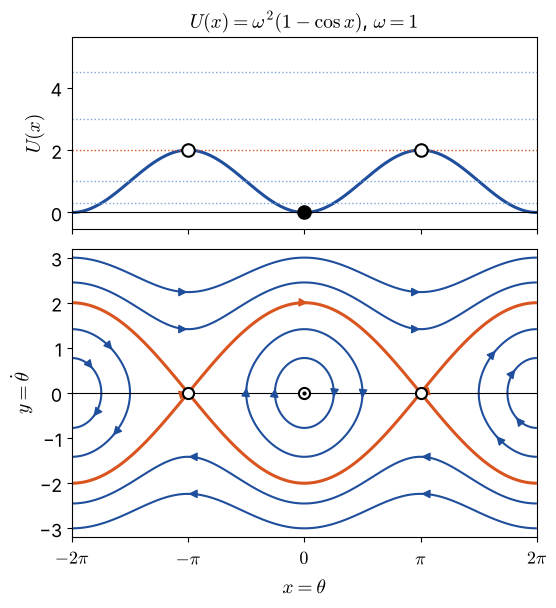

In [3]:
def potencial_y_fases(U, dU, xlim, ylim, niveles, nombre, xticks=None, sep=None, titulo=None, xlabel="$x$", ylabel=r"$y = \dot x$"):
    '''Dos paneles apilados con el mismo eje x: U(x) arriba, curvas de nivel de E = y^2/2 + U(x) abajo.
    `sep`: nivel de energía de la separatriz (se dibuja más gruesa).'''
    F = lambda t, X: [X[1], -dU(X[0])]
    xx = np.linspace(*xlim, 600); yy = np.linspace(*ylim, 400)
    X, Y = np.meshgrid(xx, yy)
    E = 0.5 * Y**2 + U(X)
    with fuente(14):
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(6, 6.5), sharex=True, gridspec_kw=dict(height_ratios=[1, 1.5], hspace=0.08))
        a1.plot(xx, U(xx), color=COLORES["traj"], lw=2.2)
        # equilibrios: puntos críticos de U (mínimos llenos, máximos vacíos)
        h = xx[1] - xx[0]
        xc = [brentq(dU, a, b) for a, b in zip(xx[1:-1], xx[2:]) if dU(a) * dU(b) < 0]
        eqs = [(x0, 0, "centro" if U(x0 + h) + U(x0 - h) > 2 * U(x0) else "silla") for x0 in xc]   # mínimo de U: centro
        for x0, _, tipo in eqs:
            a1.plot(x0, U(x0), "o", ms=9, color="black" if tipo == "centro" else "white", mec="black", mew=1.5, zorder=5)
        for c in niveles:
            a1.axhline(c, color=COLORES["traj2"], ls=":", lw=1)
        tope = max(max(niveles), sep or 0)
        a1.set_ylabel("$U(x)$"); a1.set_ylim(min(U(xx).min(), 0) - 0.12 * tope, 1.25 * tope)
        a1.axhline(0, color="black", lw=0.8)
        cs = a2.contour(X, Y, E, levels=niveles, colors=[COLORES["traj"]], linewidths=1.5)
        flechas_en_niveles(a2, cs, F)
        if sep is not None:
            a1.axhline(sep, color=COLORES["nul_h"], ls=":", lw=1)
            css = a2.contour(X, Y, E, levels=[sep], colors=[COLORES["nul_h"]], linewidths=2.2)
            flechas_en_niveles(a2, css, F, color=COLORES["nul_h"], posiciones=(0.5,))
        fases.marcar_equilibrios(a2, eqs)
        a2.axhline(0, color="black", lw=0.8)
        a2.set_xlim(*xlim); a2.set_ylim(*ylim); a2.set_xlabel(xlabel); a2.set_ylabel(ylabel)
        if xticks: a2.set_xticks(xticks[0]); a2.set_xticklabels(xticks[1])
        if titulo: a1.set_title(titulo)
        if GUARDAR: estilo.guardar(fig, nombre)
        return fig, (a1, a2)

fig, (a1, a2) = potencial_y_fases(U_pend, lambda x: w**2 * np.sin(x), (-L, L), (-3.2, 3.2),
                                  niveles=[0.3, 1.0, 3.0, 4.5], nombre="pendulo_potencial", sep=2 * w**2,
                                  xticks=([-L, -np.pi, 0, np.pi, L], [r"$-2\pi$", r"$-\pi$", "$0$", r"$\pi$", r"$2\pi$"]),
                                  titulo=rf"$U(x) = \omega^2(1-\cos x)$, $\omega = {w:g}$", xlabel=r"$x = \theta$", ylabel=r"$y = \dot\theta$");

**Figura `potencial`**: un potencial genérico con dos pozos, $U(x) = (x^2-1)^2$. Los mínimos $x=\pm1$ son centros; el máximo $x=0$ es una silla, y la curva de nivel $E = U(0) = 1$ (las "orejas" que salen de la silla) separa las oscilaciones dentro de un pozo de las que recorren los dos.

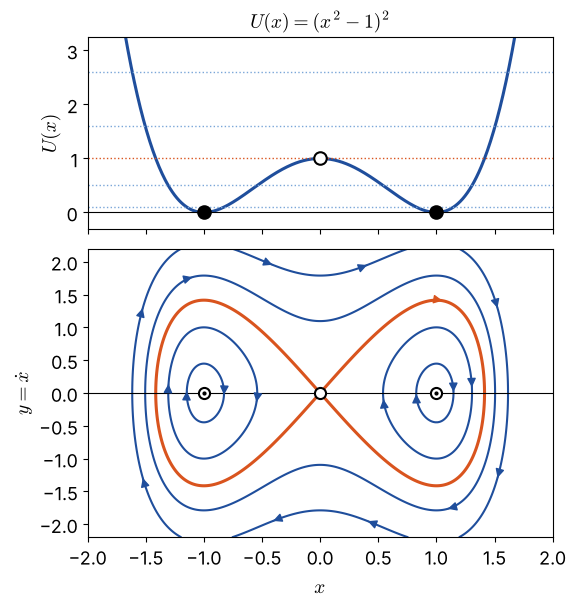

In [4]:
U_dp = lambda x: (x**2 - 1)**2
dU_dp = lambda x: 4 * x * (x**2 - 1)
fig, (a1, a2) = potencial_y_fases(U_dp, dU_dp, (-2, 2), (-2.2, 2.2), niveles=[0.1, 0.5, 1.6, 2.6], nombre="potencial", sep=1.0,
                                  titulo=r"$U(x) = (x^2-1)^2$");

## 6.2 Funciones de Lyapunov y el principio de LaSalle

$V$ es una función de Lyapunov para el equilibrio $\mathbf x^*$ si tiene ahí un mínimo estricto y $\dot V = \nabla V\cdot F \le 0$; con $\dot V<0$ fuera del equilibrio es *estricta* y el equilibrio es asintóticamente estable. Cuando $\dot V$ se anula sobre una curva (típico), el principio de LaSalle salva la situación: si ninguna trayectoria completa, salvo el equilibrio, puede quedarse en $\{\dot V = 0\}$, hay estabilidad asintótica igual.

*Figura nueva `lyapunov-pendulo`.* Izquierda: péndulo amortiguado $\dot x = y,\ \dot y = -\omega^2\sin x - 2ay$ con $V = E$; se tiene $\dot E = -2ay^2\le 0$, que se anula cada vez que la velocidad se anula (los puntos marcados): $E(t)$ es decreciente pero con tangente horizontal en esos instantes, y sin embargo baja hasta $0$ (LaSalle). Derecha: van der Pol con $V = \tfrac12(x^2+y^2)$ y $\dot V = -\lambda(x^2-1)y^2$; para $\lambda<0$ decrece dentro de la franja $|x|<1$ y la trayectoria que empieza en el disco $V<1/2$ converge al origen; para $\lambda>0$ crece hasta que $|x|$ supera $1$.

péndulo amortiguado: max|dE/dt + 2 a y^2| = 7.9e-05;  E decrece: True


van der Pol lambda = -0.5: max|dV/dt + lambda (x^2-1) y^2| = 2.1e-05


van der Pol lambda = 0.5: max|dV/dt + lambda (x^2-1) y^2| = 4.9e-03


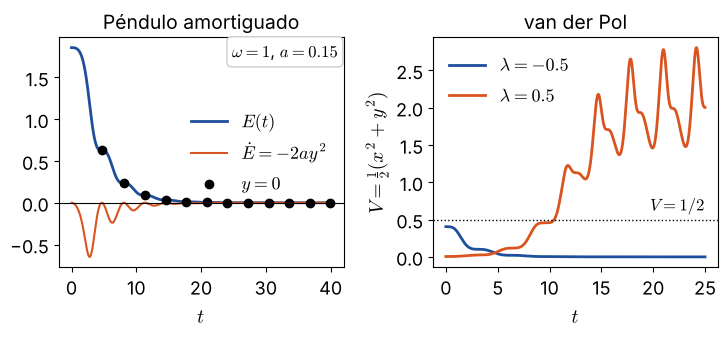

In [5]:
def pendulo_amortiguado(t, X, w, a):
    x, y = X
    return [y, -w**2 * np.sin(x) - 2 * a * y]

def vdP(t, X, lam):
    x, y = X
    return [y, -x - lam * (x**2 - 1) * y]

V_vdp = lambda x, y: 0.5 * (x**2 + y**2)
a = 0.15
t, (x, y) = simular(pendulo_amortiguado, [2.6, 0.0], 40, args=(w, a))
E = E_pend(x, y)
dE_num = np.gradient(E, t)
print(f"péndulo amortiguado: max|dE/dt + 2 a y^2| = {np.abs(dE_num + 2 * a * y**2).max():.1e};  E decrece: {np.all(np.diff(E) <= 1e-12)}")

with fuente(14):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.6))
    ax1.plot(t, E, lw=2, label="$E(t)$")
    ax1.plot(t, -2 * a * y**2, color=COLORES["nul_h"], lw=1.5, label=r"$\dot E = -2ay^2$")
    k = np.where((y[:-1] * y[1:]) < 0)[0]     # instantes con y = 0
    ax1.plot(t[k], E[k], "o", ms=6, color="black", label=r"$y = 0$")
    ax1.axhline(0, color="black", lw=0.8)
    ax1.set_xlabel("$t$"); ax1.legend(loc="center right")
    estilo.parametros(ax1, rf"$\omega = {w:g}$, $a = {a}$", loc="upper right", fontsize=12)
    ax1.set_title("Péndulo amortiguado")
    for lam, X0, c in [(-0.5, [0.9, 0.0], CICLO[0]), (0.5, [0.1, 0.0], CICLO[1])]:
        t, (x, y) = simular(vdP, X0, 25, args=(lam,))
        V = V_vdp(x, y)
        ax2.plot(t, V, color=c, lw=2, label=rf"$\lambda = {lam}$")
        dV_num = np.gradient(V, t)
        print(f"van der Pol lambda = {lam}: max|dV/dt + lambda (x^2-1) y^2| = {np.abs(dV_num + lam * (x**2 - 1) * y**2).max():.1e}")
    ax2.axhline(0.5, color="black", ls=":", lw=1); ax2.text(25, 0.55, "$V = 1/2$", ha="right", va="bottom", fontsize=12)
    ax2.set_xlabel("$t$"); ax2.set_ylabel(r"$V = \frac{1}{2}(x^2+y^2)$"); ax2.legend(loc="upper left")
    ax2.set_title("van der Pol")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "lyapunov-pendulo")

**Lotka–Volterra con capacidad de carga** (Observación del texto): para $\dot h = \rho h(1-h/k-p)$, $\dot p = -\frac1\rho p(1-h)$ y $p^* = 1-1/k$, la función $V(h,p) = (h-\ln h) + \rho^2(p - p^*\ln p)$ verifica $\dot V = -\frac{\rho}{k}(h-1)^2 \le 0$. Se anula sobre la recta $h=1$, pero una trayectoria que se quede en $h=1$ tiene $\dot h = 0$, luego $p = p^*$: es el equilibrio. LaSalle da que $(1,p^*)$ atrae a todo el cuadrante positivo.

In [6]:
def LV2(t, X, rho, k):
    h, p = X
    return [rho * h * (1 - h / k - p), -p * (1 - h) / rho]

rho, k = 1.0, 2.0
ps = 1 - 1 / k
V_LV2 = lambda h, p: (h - np.log(h)) + rho**2 * (p - ps * np.log(p))
t, (h, p) = simular(LV2, [0.2, 1.5], 40, args=(rho, k))
V = V_LV2(h, p)
print(f"max|dV/dt + (rho/k)(h-1)^2| = {np.abs(np.gradient(V, t) + rho / k * (h - 1)**2).max():.1e}")
print(f"V(0) = {V[0]:.4f} -> V(T) = {V[-1]:.4f};  V(1, p*) = {V_LV2(1, ps):.4f};  (h, p)(T) = ({h[-1]:.4f}, {p[-1]:.4f}), p* = {ps}")

max|dV/dt + (rho/k)(h-1)^2| = 9.4e-04
V(0) = 3.1067 -> V(T) = 1.8466;  V(1, p*) = 1.8466;  (h, p)(T) = (0.9999, 0.5001), p* = 0.5


### Volvemos al circuito: van der Pol

**Figura `vanderPol`**: sistema $\dot x = y,\ \dot y = -x-\lambda(x^2-1)y$. A la izquierda, $\lambda = 0.5$: el origen es inestable y las trayectorias (una que sale de cerca del origen, otra que entra desde afuera) convergen a un ciclo límite, en trazo grueso. A la derecha, $\lambda = -0.5$: el origen es asintóticamente estable; el ciclo límite es ahora inestable (es el mismo ciclo recorrido con el tiempo invertido: $(x,y)\mapsto(x,-y)$) y separa las trayectorias que convergen al origen de las que escapan.

El ciclo se obtiene integrando mucho tiempo y quedándose con el último tramo; en la celda siguiente se miden su amplitud y su período.

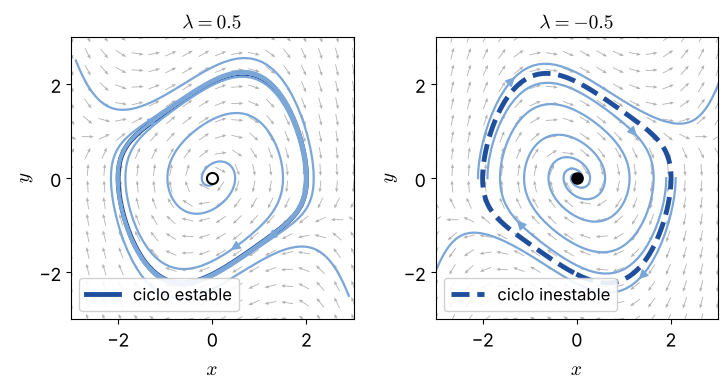

In [7]:
def ciclo_vdp(lam, T=200):
    '''Ciclo límite de van der Pol (lambda > 0): último período de una trayectoria larga.'''
    t, (x, y) = simular(vdP, [2.0, 0.0], T, args=(lam,), n=20000)
    k = np.where((x[:-1] < 0) & (x[1:] >= 0))[0]        # cruces ascendentes de x = 0
    i0, i1 = k[-2], k[-1]
    return x[i0:i1 + 1], y[i0:i1 + 1], t[i1] - t[i0]

xc, yc, Tc = ciclo_vdp(0.5)
R = 3.0
with fuente(14):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.9))
    # lambda = 0.5: ciclo estable
    fases.campo(vdP, (-R, R), (-R, R), ax=ax1, n=18, args=(0.5,))
    ax1.plot(xc, yc, color=COLORES["traj"], lw=3.5, label="ciclo estable")
    for X0 in [(0.1, 0.0), (-2.9, 2.5), (2.9, -2.5)]:
        fases.trayectoria(vdP, X0, 25, ax=ax1, args=(0.5,), color=COLORES["traj2"], lw=1.6, pos_flecha=0.3)
    fases.marcar_equilibrios(ax1, [(0, 0, "inestable")])
    ax1.set_title(r"$\lambda = 0.5$")
    # lambda = -0.5: el mismo ciclo, recorrido al revés, es inestable
    fases.campo(vdP, (-R, R), (-R, R), ax=ax2, n=18, args=(-0.5,))
    ax2.plot(xc, -yc, color=COLORES["traj"], lw=3.5, ls="--", label="ciclo inestable")
    for X0 in [(1.9, 0.0), (-1.9, 0.0), (2.1, 0.0), (-2.1, 0.0)]:
        fases.trayectoria(vdP, X0, 25, ax=ax2, args=(-0.5,), color=COLORES["traj2"], lw=1.6, pos_flecha=0.3)
    fases.marcar_equilibrios(ax2, [(0, 0, "estable")])
    ax2.set_title(r"$\lambda = -0.5$")
    for ax in (ax1, ax2):
        ax.set_xlim(-R, R); ax.set_ylim(-R, R); ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_aspect("equal")
        ax.set_xticks([-2, 0, 2]); ax.set_yticks([-2, 0, 2])
        ax.legend(loc="lower left", fontsize=12, frameon=True, framealpha=0.9)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "vanderPol")

**Amplitud y período del ciclo.** El Teorema de Liénard dice que para todo $\lambda>0$ hay un único ciclo, que atrae a todo salvo el origen. El texto afirma que para $\lambda$ chico el ciclo es casi una circunferencia de radio $2$ con período cercano a $2\pi$, y que para $\lambda$ grande el período crece como $\lambda$ (oscilaciones de relajación).

In [8]:
print(f"{'lambda':>7} {'amplitud':>9} {'período':>8} {'T/2pi':>7} {'T/lambda':>9}")
for lam in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    xc, yc, Tc = ciclo_vdp(lam, T=60 * max(1, lam))
    print(f"{lam:7.1f} {xc.max():9.4f} {Tc:8.4f} {Tc / (2 * np.pi):7.4f} {Tc / lam:9.4f}")

 lambda  amplitud  período   T/2pi  T/lambda


    0.1    2.0001   6.2883  1.0008   62.8831


    0.5    2.0025   6.3813  1.0156   12.7626


    1.0    2.0086   6.6633  1.0605    6.6633


    2.0    2.0199   7.6264  1.2138    3.8132


    5.0    2.0215  11.6106  1.8479    2.3221


   10.0    2.0142  19.0810  3.0368    1.9081


## 7.1–7.2 Conjuntos límite y el Teorema de Poincaré–Bendixson

En dimensión tres el $\omega$-límite de una trayectoria puede ser un objeto complicado: el atractor de Lorenz,
$$\dot x = \sigma(y-x),\qquad \dot y = x(\rho-z)-y,\qquad \dot z = xy-\beta z,$$
con $\sigma = 10$, $\rho = 28$, $\beta = 8/3$ (**figura `Lorenz`**). En dimensión dos esto no pasa: un conjunto límite compacto sin equilibrios es una órbita cerrada (Poincaré–Bendixson).

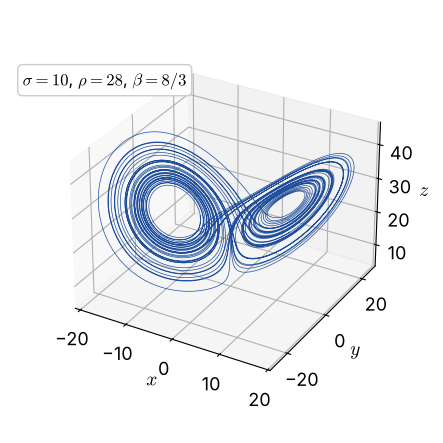

In [9]:
def lorenz(t, X, sigma, rho, beta):
    x, y, z = X
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

sigma, rho_L, beta = 10.0, 28.0, 8 / 3
sol = solve_ivp(lorenz, (0, 60), [1.0, 1.0, 1.0], args=(sigma, rho_L, beta), rtol=1e-9, atol=1e-11, dense_output=True)
t = np.linspace(10, 60, 30000)     # descartamos el transitorio inicial
x, y, z = sol.sol(t)
with fuente(14):
    fig = plt.figure(figsize=(6, 5.5))
    ax = fig.add_subplot(projection="3d")
    ax.plot(x, y, z, color=COLORES["traj"], lw=0.5)
    ax.set_box_aspect(None, zoom=0.82)
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_zlabel("$z$")
    ax.set_xticks([-20, -10, 0, 10, 20]); ax.set_yticks([-20, 0, 20]); ax.set_zticks([10, 20, 30, 40])
    ax.text2D(0.03, 0.82, rf"$\sigma = {sigma:g}$, $\rho = {rho_L:g}$, $\beta = 8/3$", transform=ax.transAxes, fontsize=12,
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8"))
    if GUARDAR: estilo.guardar(fig, "Lorenz")

**Figura `ciclo_limite`** (Ejemplo del texto): $\dot x = x - y - x(x^2+y^2)$, $\dot y = x + y - y(x^2+y^2)$, que en polares es $\dot r = r - r^3$, $\dot\theta = 1$. El anillo $D = \{r_1 \le r \le r_2\}$ con $r_1 < 1 < r_2$ es positivamente invariante (en el borde interior $\dot r>0$, en el exterior $\dot r<0$: el campo apunta hacia adentro de $D$) y no contiene equilibrios, así que por Poincaré–Bendixson contiene un ciclo límite: la circunferencia $r=1$. La figura agrega el anillo sombreado, que el texto describe.

r = 0.5: r' = r - r^3 = +0.375
r = 1.5: r' = r - r^3 = -1.875


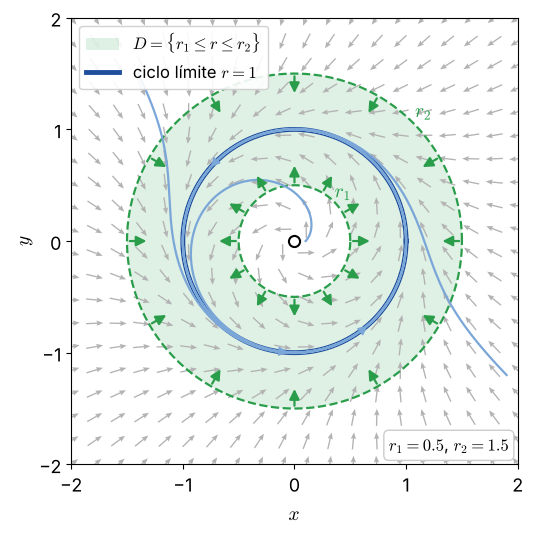

In [10]:
def ejemplo_ciclo(t, X):
    x, y = X
    r2 = x**2 + y**2
    return [x - y - x * r2, x + y - y * r2]

r1, r2 = 0.5, 1.5
# Verificación: signo de r' = r - r^3 en los dos bordes del anillo
for r in (r1, r2):
    print(f"r = {r}: r' = r - r^3 = {r - r**3:+.3f}")

with fuente(14):
    fig, ax = plt.subplots(figsize=(6, 5.8))
    th = np.linspace(0, 2 * np.pi, 400)
    ax.fill(np.concatenate([r2 * np.cos(th), r1 * np.cos(th[::-1])]), np.concatenate([r2 * np.sin(th), r1 * np.sin(th[::-1])]),
            color=COLORES["nul_p"], alpha=0.15, lw=0, label=r"$D = \{r_1 \leq r \leq r_2\}$")
    for r in (r1, r2):
        ax.plot(r * np.cos(th), r * np.sin(th), color=COLORES["nul_p"], lw=1.6, ls="--")
        for phi in np.linspace(0, 2 * np.pi, 12, endpoint=False):   # componente radial del campo: r' = r - r^3 apunta hacia adentro de D
            u = np.array([np.cos(phi), np.sin(phi)]); p = r * u
            d = 0.2 * np.sign(r - r**3) * u
            ax.annotate("", xy=p + d, xytext=p, arrowprops=dict(arrowstyle="-|>", color=COLORES["nul_p"], mutation_scale=15, lw=1.6))
    fases.campo(ejemplo_ciclo, (-2, 2), (-2, 2), ax=ax, n=20)
    ax.plot(np.cos(th), np.sin(th), color=COLORES["traj"], lw=3.5, label="ciclo límite $r = 1$")
    for X0 in [(0.1, 0.0), (1.9, -1.2), (-1.4, 1.5)]:
        fases.trayectoria(ejemplo_ciclo, X0, 12, ax=ax, color=COLORES["traj2"], lw=1.6, pos_flecha=0.3)
    fases.marcar_equilibrios(ax, [(0, 0, "inestable")])
    ax.text(r1 * 0.72, r1 * 0.72 + 0.03, "$r_1$", color=COLORES["nul_p"], fontsize=14)
    ax.text(r2 * 0.72, r2 * 0.72 + 0.03, "$r_2$", color=COLORES["nul_p"], fontsize=14)
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect("equal"); ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    ax.set_xticks([-2, -1, 0, 1, 2]); ax.set_yticks([-2, -1, 0, 1, 2])
    ax.legend(loc="upper left", fontsize=12, frameon=True, framealpha=0.9)
    estilo.parametros(ax, rf"$r_1 = {r1}$, $r_2 = {r2}$", loc="lower right", fontsize=12)
    if GUARDAR: estilo.guardar(fig, "ciclo_limite")

## 7.3 Estudio gráfico: competencia de especies

Adimensionalizado,
$$n_1' = \rho\, n_1(1-n_1) - \alpha_1 n_1 n_2,\qquad n_2' = \tfrac1\rho\, n_2(1-n_2) - \alpha_2 n_1 n_2,$$
con nulclinas (fuera de los ejes) $\mathcal N_1 = \{\rho(1-n_1) = \alpha_1 n_2\}$ y $\mathcal N_2 = \{\frac1\rho(1-n_2) = \alpha_2 n_1\}$. Con $a_1 = \rho/\alpha_1$ y $a_2 = 1/(\rho\alpha_2)$, $\mathcal N_1$ es la recta que une $(1, 0)$ con $(0, a_1)$ y $\mathcal N_2$ la que une $(a_2, 0)$ con $(0, 1)$; se cortan en el cuadrante positivo si y sólo si $a_1, a_2 > 1$ o $a_1, a_2 < 1$, en el punto
$$n_1^* = \frac{a_2(1-a_1)}{1-a_1a_2},\qquad n_2^* = \frac{a_1(1-a_2)}{1-a_1a_2}.$$

**Figura `nulclinas`**: nulclinas, equilibrios y sentido del campo en cada región, en los casos $a_i>1$ (izquierda) y $a_i<1$ (derecha). Corrección respecto de la figura original: nulclinas y equilibrios etiquetados.

a_1, a_2 > 1: rho = 1.0, alpha1 = 0.6, alpha2 = 0.8  ->  a1 = 1.667, a2 = 1.250
a_1, a_2 < 1: rho = 1.0, alpha1 = 1.4, alpha2 = 1.25  ->  a1 = 0.714, a2 = 0.800


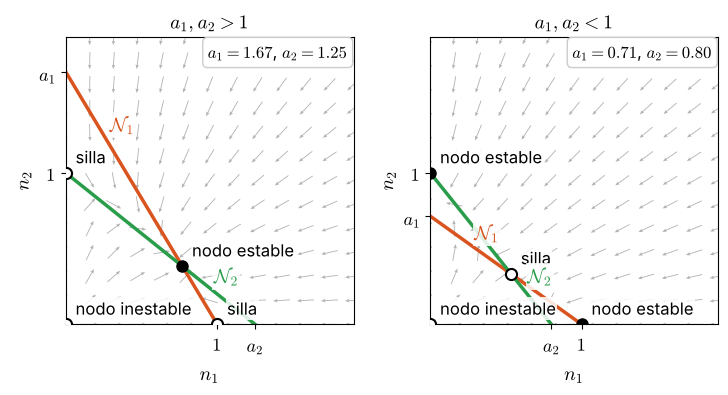

In [11]:
def competencia(t, X, rho, al1, al2):
    n1, n2 = X
    return [rho * n1 * (1 - n1) - al1 * n1 * n2, n2 * (1 - n2) / rho - al2 * n1 * n2]

def aes(rho, al1, al2):
    return rho / al1, 1 / (rho * al2)

def equilibrios_competencia(rho, al1, al2):
    '''Los equilibrios (0,0), (1,0), (0,1) y, si está en el cuadrante positivo, el de coexistencia, clasificados con el jacobiano.'''
    a1, a2 = aes(rho, al1, al2)
    eqs = [(0.0, 0.0), (1.0, 0.0), (0.0, 1.0)]
    if (a1 - 1) * (a2 - 1) > 0:
        eqs.append((a2 * (1 - a1) / (1 - a1 * a2), a1 * (1 - a2) / (1 - a1 * a2)))
    return [(x, y, fases.clasificar(fases.jacobiano(competencia, [x, y], args=(rho, al1, al2)))) for x, y in eqs]

def dibujar_nulclinas(ax, rho, al1, al2, lim, campo=True, etiquetas=True):
    '''Nulclinas N1, N2 y equilibrios (llenos: estables; vacíos: sillas o inestables) del sistema de competencia.
    Con `etiquetas`, escribe el tipo de cada equilibrio y el nombre de cada nulclina.'''
    a1, a2 = aes(rho, al1, al2)
    if campo:
        fases.campo(competencia, (0, lim), (0, lim), ax=ax, n=13, args=(rho, al1, al2))
    ax.plot([0, 1], [a1, 0], color=COLORES["nul_h"], lw=2.5, label=r"$\mathcal{N}_1$")
    ax.plot([0, a2], [1, 0], color=COLORES["nul_p"], lw=2.5, label=r"$\mathcal{N}_2$")
    eqs = equilibrios_competencia(rho, al1, al2)
    fases.marcar_equilibrios(ax, [(x, y, "estable" if tipo.endswith(" estable") else "inestable") for x, y, tipo in eqs])
    if etiquetas:
        caja = dict(fc="white", ec="none", alpha=0.85, pad=1)
        for x, y, tipo in eqs:
            ax.annotate(tipo, (x, y), (7, 7), textcoords="offset points", fontsize=12, bbox=caja)
        ax.text(0.25 + 0.04, 0.75 * a1 + 0.02, r"$\mathcal{N}_1$", color=COLORES["nul_h"], fontsize=14, bbox=caja)
        ax.text(0.75 * a2 + 0.04, 0.25 + 0.02, r"$\mathcal{N}_2$", color=COLORES["nul_p"], fontsize=14, bbox=caja)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
    ax.set_xticks([1, a2]); ax.set_xticklabels(["$1$", "$a_2$"]); ax.set_yticks([1, a1]); ax.set_yticklabels(["$1$", "$a_1$"])
    ax.set_xlabel("$n_1$"); ax.set_ylabel("$n_2$")
    return a1, a2

rho = 1.0
casos = {"a_1, a_2 > 1": (0.6, 0.8), "a_1, a_2 < 1": (1.4, 1.25), "a_1 < 1 < a_2": (1.4, 0.8), "a_2 < 1 < a_1": (0.6, 1.25)}
with fuente(14):
    fig, axs = plt.subplots(1, 2, figsize=(7.5, 4.0))
    for ax, nombre in zip(axs, ["a_1, a_2 > 1", "a_1, a_2 < 1"]):
        al1, al2 = casos[nombre]
        a1, a2 = dibujar_nulclinas(ax, rho, al1, al2, lim=1.9)
        ax.set_title(f"${nombre}$")
        estilo.parametros(ax, rf"$a_1 = {a1:.2f}$, $a_2 = {a2:.2f}$", loc="upper right", fontsize=12)
        print(f"{nombre}: rho = {rho}, alpha1 = {al1}, alpha2 = {al2}  ->  a1 = {a1:.3f}, a2 = {a2:.3f}")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "nulclinas")

*Figura nueva `competencia-retratos`*: retratos de fase de los cuatro casos. El texto afirma que el equilibrio de coexistencia es asintóticamente estable si $a_1,a_2>1$ y silla si $a_1,a_2<1$ (biestabilidad: gana la especie que empieza con ventaja), y deja como ejercicio los casos mixtos, en los que no hay coexistencia: una especie excluye a la otra.

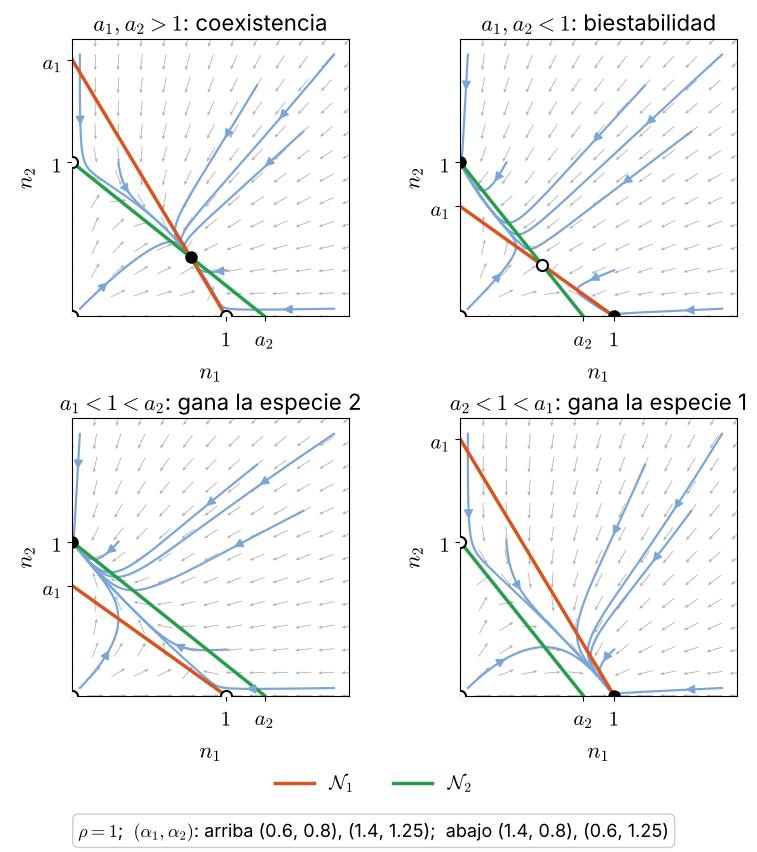

In [12]:
titulos = {"a_1, a_2 > 1": "coexistencia", "a_1, a_2 < 1": "biestabilidad",
           "a_1 < 1 < a_2": "gana la especie 2", "a_2 < 1 < a_1": "gana la especie 1"}
with fuente(16):
    fig, axs = plt.subplots(2, 2, figsize=(8, 8.6))
    inicios = [(0.05, 0.05), (0.05, 1.7), (1.7, 0.05), (1.7, 1.7), (0.3, 1.0), (1.0, 0.3), (1.2, 1.5), (1.5, 1.2)]
    for ax, (nombre, (al1, al2)) in zip(axs.flat, casos.items()):
        for X0 in inicios:
            fases.trayectoria(competencia, X0, 40, ax=ax, args=(rho, al1, al2), color=COLORES["traj2"], lw=1.6, pos_flecha=0.25)
        a1, a2 = dibujar_nulclinas(ax, rho, al1, al2, lim=1.8, etiquetas=False)
        ax.set_title(f"${nombre}$: {titulos[nombre]}")
    # parámetros de los cuatro paneles en un solo recuadro, fuera de los paneles
    vals = list(casos.values())
    texto = rf"$\rho = {rho:g}$;  $(\alpha_1, \alpha_2)$: arriba {vals[0]}, {vals[1]};  abajo {vals[2]}, {vals[3]}"
    fig.text(0.5, 0.015, texto, ha="center", va="bottom", fontsize=13, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8"))
    fig.legend(*axs[0, 0].get_legend_handles_labels(), loc="lower center", ncol=2, fontsize=14, bbox_to_anchor=(0.5, 0.05))
    fig.tight_layout(rect=(0, 0.09, 1, 1))
    if GUARDAR: estilo.guardar(fig, "competencia-retratos")

In [13]:
# Verificación: clasificación de todos los equilibrios con el jacobiano numérico, caso por caso
for nombre, (al1, al2) in casos.items():
    a1, a2 = aes(rho, al1, al2)
    print(f"{nombre}  (a1 = {a1:.2f}, a2 = {a2:.2f})")
    for x, y, tipo in equilibrios_competencia(rho, al1, al2):
        J = fases.jacobiano(competencia, [x, y], args=(rho, al1, al2))
        print(f"   ({x:.3f}, {y:.3f}): {tipo:15s} autovalores {np.round(np.linalg.eigvals(J), 3)}")

a_1, a_2 > 1  (a1 = 1.67, a2 = 1.25)
   (0.000, 0.000): nodo inestable  autovalores [1.+0.j 1.+0.j]
   (1.000, 0.000): silla           autovalores [-1. +0.j  0.2+0.j]
   (0.000, 1.000): silla           autovalores [-1. +0.j  0.4+0.j]
   (0.769, 0.385): nodo estable    autovalores [-1.   +0.j -0.154+0.j]
a_1, a_2 < 1  (a1 = 0.71, a2 = 0.80)
   (0.000, 0.000): nodo inestable  autovalores [1.+0.j 1.+0.j]
   (1.000, 0.000): nodo estable    autovalores [-1.  +0.j -0.25+0.j]
   (0.000, 1.000): nodo estable    autovalores [-1. +0.j -0.4+0.j]
   (0.533, 0.333): silla           autovalores [-1.   +0.j  0.133+0.j]
a_1 < 1 < a_2  (a1 = 0.71, a2 = 1.25)
   (0.000, 0.000): nodo inestable  autovalores [1.+0.j 1.+0.j]
   (1.000, 0.000): silla           autovalores [-1. +0.j  0.2+0.j]
   (0.000, 1.000): nodo estable    autovalores [-1. +0.j -0.4+0.j]
a_2 < 1 < a_1  (a1 = 1.67, a2 = 0.80)
   (0.000, 0.000): nodo inestable  autovalores [1.+0.j 1.+0.j]
   (1.000, 0.000): nodo estable    autovalores [-1. 

## Para experimentar

1. En `potencial_y_fases`, probá con $U(x) = x^2/2 - x^3/3$ (un pozo con una barrera de un solo lado): ¿cuáles trayectorias escapan a $-\infty$?
2. Para el péndulo amortiguado, encontrá numéricamente la cuenca de atracción de $(0,0)$ dentro de la franja $|x|<\pi$ y compará con el pozo $\{E<2\omega^2\}$ que garantiza el argumento de energía: ¿es más grande?
3. Cambiá $r_1$ y $r_2$ en la figura `ciclo_limite`. ¿Qué pasa con el anillo si $r_2 < 1$?
4. En competencia, con $a_1,a_2<1$, dibujá la separatriz (variedad estable de la silla, integrando hacia atrás desde ella): es la frontera entre las dos cuencas de atracción.